In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/3_Car_Evaluation_Dataset (2).csv')

# Display first  5 rows
df.head()


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


### **DATASET Description**

The Car Evaluation dataset evaluates car acceptability based on several categorical attributes such as buying price, maintenance cost, safety level, passenger capacity, and luggage boot size. The target variable "class" categorizes cars into four classes: unacc, acc, good, and vgood.

### **DATASET DETAILS**

In [2]:
# Number of samples and features and missing values
num_samples = df.shape[0]
num_features = df.shape[1] - 1
total_missing=df.isnull().sum().sum()
print("Number of samples:", num_samples)
print("Number of features:", num_features)
print("Total missing values:",total_missing)


Number of samples: 1728
Number of features: 6
Total missing values: 0


In [3]:

num_classes = df["class"].nunique()
class_distribution = df["class"].value_counts()

print("Number of classes:", num_classes)
print("\nClass distribution:")
print(class_distribution)


Number of classes: 4

Class distribution:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


### **DATA** **VISUALIZATION**

In [4]:
#Importing the essential libraries required for this part.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


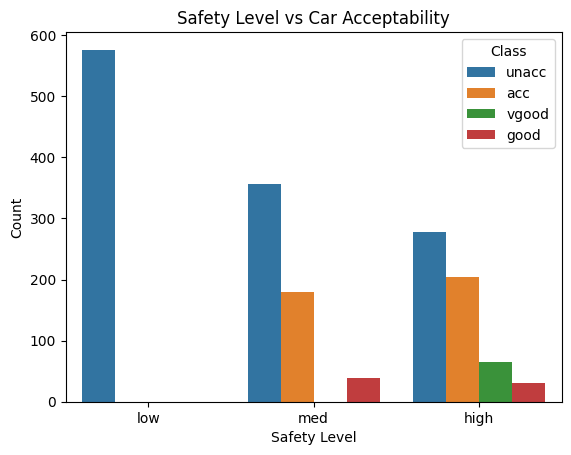

In [5]:
plt.figure()
sns.countplot(data=df,x="safety",hue="class")
plt.title("Safety Level vs Car Acceptability")
plt.xlabel("Safety Level")
plt.ylabel("Count")
plt.legend(title="Class")
plt.show()



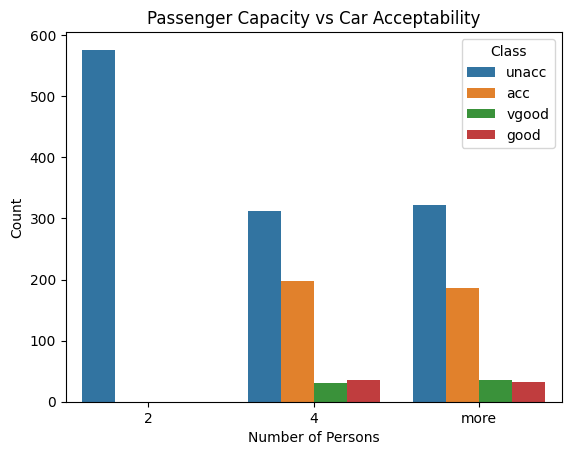

In [6]:
plt.figure()
sns.countplot(data=df,x="persons",hue="class")
plt.title("Passenger Capacity vs Car Acceptability")
plt.xlabel("Number of Persons")
plt.ylabel("Count")
plt.legend(title="Class")
plt.show()



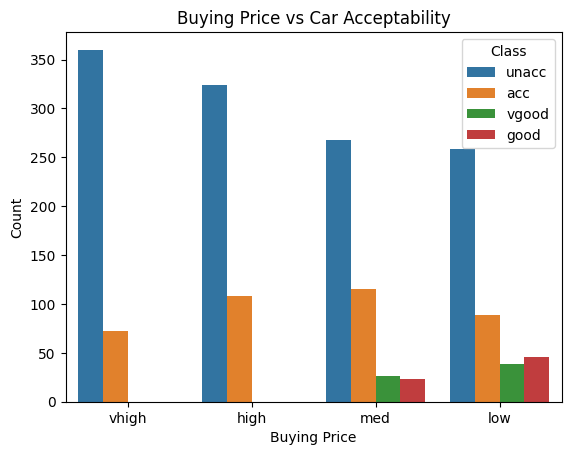

In [7]:
plt.figure()
sns.countplot(data=df,x="buying",hue="class")
plt.title("Buying Price vs Car Acceptability")
plt.xlabel("Buying Price")
plt.ylabel("Count")
plt.legend(title="Class")
plt.show()



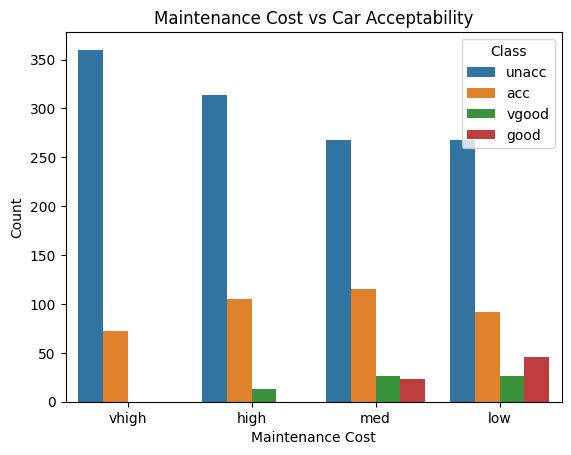

In [8]:
plt.figure()
sns.countplot(data=df,x="maint",hue="class")
plt.title("Maintenance Cost vs Car Acceptability")
plt.xlabel("Maintenance Cost")
plt.ylabel("Count")
plt.legend(title="Class")
plt.show()



### **Data** **Preprocessing**

In [9]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
df_encoded=df.copy()
x=df_encoded.drop("class",axis=1)
y=df_encoded["class"]

encoder=OneHotEncoder(sparse_output= False ,handle_unknown='ignore')
print("Feature shape before encoding:",x.shape)
print("Target shape:",y.shape)


Feature shape before encoding: (1728, 6)
Target shape: (1728,)


### **Performing 5-Fold Stratified Cross Validation**

In [10]:
from sklearn.model_selection import StratifiedKFold
# define stratified 5-fold
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=0)

# perform split
for fold,(train_index,test_index) in enumerate(skf.split(x,y)):

    x_train,x_test=x.iloc[train_index],x.iloc[test_index]
    y_train,y_test=y.iloc[train_index],y.iloc[test_index]

    print("Fold",fold+1)
    print("Training samples:",len(train_index))
    print("Testing samples:",len(test_index))
    print("----------------------")


Fold 1
Training samples: 1382
Testing samples: 346
----------------------
Fold 2
Training samples: 1382
Testing samples: 346
----------------------
Fold 3
Training samples: 1382
Testing samples: 346
----------------------
Fold 4
Training samples: 1383
Testing samples: 345
----------------------
Fold 5
Training samples: 1383
Testing samples: 345
----------------------


### **Verification of Class Distribution in Each Fold**

In [11]:
for fold,(train_index,test_index) in enumerate(skf.split(x,y)):

    print("Fold",fold+1)

    print("Train class distribution:")
    print(y.iloc[train_index].value_counts(normalize=True))

    print("Test class distribution:")
    print(y.iloc[test_index].value_counts(normalize=True))

    print("----------------------")


Fold 1
Train class distribution:
class
unacc    0.700434
acc      0.222142
good     0.039797
vgood    0.037627
Name: proportion, dtype: float64
Test class distribution:
class
unacc    0.699422
acc      0.222543
good     0.040462
vgood    0.037572
Name: proportion, dtype: float64
----------------------
Fold 2
Train class distribution:
class
unacc    0.700434
acc      0.222142
good     0.039797
vgood    0.037627
Name: proportion, dtype: float64
Test class distribution:
class
unacc    0.699422
acc      0.222543
good     0.040462
vgood    0.037572
Name: proportion, dtype: float64
----------------------
Fold 3
Train class distribution:
class
unacc    0.700434
acc      0.222142
good     0.039797
vgood    0.037627
Name: proportion, dtype: float64
Test class distribution:
class
unacc    0.699422
acc      0.222543
good     0.040462
vgood    0.037572
Name: proportion, dtype: float64
----------------------
Fold 4
Train class distribution:
class
unacc    0.699928
acc      0.221981
good     0.04049

### **Feature Scaling funcion  for KNN, SVM, and MLP:**

In [12]:
from sklearn.preprocessing import StandardScaler
def scale(x, train_index, test_index):
    X_train = x.iloc[train_index]
    X_test = x.iloc[test_index]
    encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore')

    X_train = encoder.fit_transform(X_train)
    X_test = encoder.transform(X_test)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test


### **KNN Section:-**

In [13]:
#Importing the essential libraries required for this part.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score,precision_score,recall_score
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [14]:

k_values = [1,3,5,7,9]
acc_vals= []
for k in k_values:

    acc_list = []
    f1_list = []
    precision_list = []
    sensitivity_list = []
    specificity_list = []

    for train_index, test_index in skf.split(x, y):

        X_train, X_test = scale(x, train_index, test_index)
        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        knn = KNeighborsClassifier(n_neighbors=k, metric= 'euclidean')
        knn.fit(X_train, y_train)

        y_pred = knn.predict(X_test)

        # metrics
        acc_list.append(accuracy_score(y_test, y_pred))
        f1_list.append(f1_score(y_test, y_pred, average='weighted'))
        precision_list.append(precision_score(y_test, y_pred, average='weighted', zero_division=0))

        # sensitivity = recall
        sensitivity_list.append(recall_score(y_test, y_pred, average='macro'))
        cm = confusion_matrix(y_test, y_pred)

        spec = []
        for i in range(len(cm)):
            FP = cm[:, i].sum() - cm[i, i]
            TN = cm.sum() - (cm[i, :].sum() + FP)
            spec.append(TN / (TN + FP))

        specificity_list.append(np.mean(spec))

    acc_vals.append(np.mean(acc_list))          # used for the plot later
    print("K =", k)
    print("Accuracy =", np.mean(acc_list), "±", np.std(acc_list))
    print("F1 Score =", np.mean(f1_list), "±", np.std(f1_list))
    print("Precision Score =", np.mean(precision_list), "±", np.std(precision_list))
    print("Sensitivity =", np.mean(sensitivity_list), "±", np.std(sensitivity_list))
    print("Specificity =", np.mean(specificity_list), "±", np.std(specificity_list))
    print("----------------------")


K = 1
Accuracy = 0.7297545446929714 ± 0.04134869134443303
F1 Score = 0.7294811407061771 ± 0.03966071920119186
Precision Score = 0.7313900331807711 ± 0.0397188343607497
Sensitivity = 0.44902836398051715 ± 0.07912797949077786
Specificity = 0.8617847389916318 ± 0.021604889818287756
----------------------
K = 3
Accuracy = 0.7667437379576109 ± 0.04090298851522712
F1 Score = 0.7532826797788867 ± 0.045510901441841486
Precision Score = 0.750814362826483 ± 0.058992276684524586
Sensitivity = 0.4409299432624792 ± 0.0787362727460577
Specificity = 0.8723667383765307 ± 0.030441760367990442
----------------------
K = 5
Accuracy = 0.8292787132445338 ± 0.0205951188937513
F1 Score = 0.8080077408546977 ± 0.025264012043167843
Precision Score = 0.7981672901456275 ± 0.0315189671605378
Sensitivity = 0.46967924420077534 ± 0.044205387871921964
Specificity = 0.8938924194655815 ± 0.014879594688802162
----------------------
K = 7
Accuracy = 0.8767462511518808 ± 0.02405795135326252
F1 Score = 0.867651449609118 ± 0

### **plot showing performance vs K**

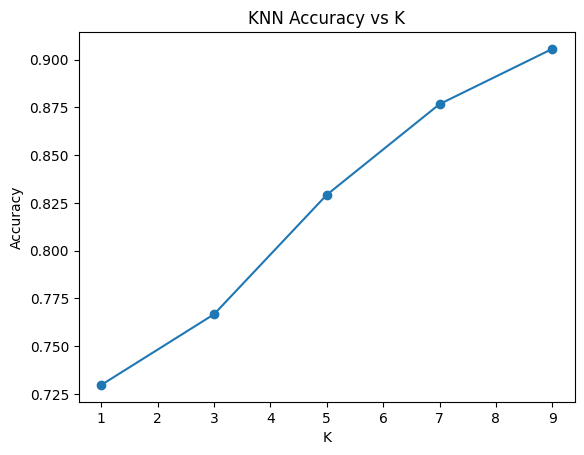

In [15]:
plt.plot(k_values, acc_vals,marker = 'o')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.show()

# Confusion matrix for the best K:

In [16]:
all_true = []
all_pred = []

for train_index, test_index in skf.split(x, y):

    X_train, X_test = scale(x, train_index, test_index)
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    knn = KNeighborsClassifier(n_neighbors=9)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    all_true.extend(y_test)
    all_pred.extend(y_pred)

cm = confusion_matrix(all_true, all_pred)

print("Confusion Matrix:")
print("Rows = Actual, Columns = Predicted")
print(cm)

Confusion Matrix:
Rows = Actual, Columns = Predicted
[[ 312    4   68    0]
 [  42   23    2    2]
 [  16    1 1193    0]
 [  23    5    0   37]]


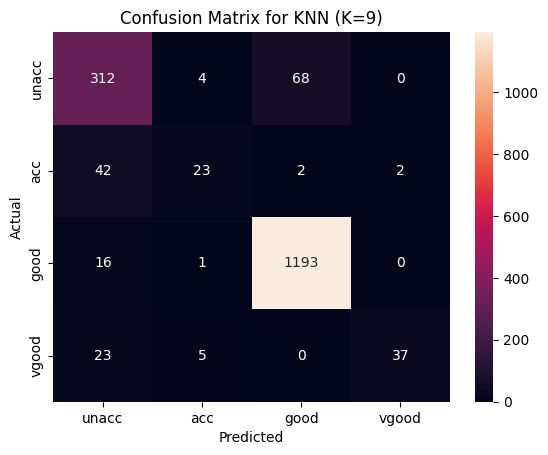

In [17]:

labels = ["unacc", "acc", "good", "vgood"]

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for KNN (K=9)")
plt.show()

### **SVM section:-**

In [18]:
#Importing the essential libraries required for this part.
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score,precision_score,recall_score,confusion_matrix
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt



In [19]:
kernels = ['linear','rbf','poly']

for kernel in kernels:

    acc_list = []
    f1_list = []
    precision_list = []
    sensitivity_list = []
    specificity_list = []

    for train_index, test_index in skf.split(x, y):

        X_train, X_test = scale(x, train_index, test_index)
        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        svm = SVC(kernel=kernel, random_state=0)
        svm.fit(X_train, y_train)

        y_pred = svm.predict(X_test)

        # metrics
        acc_list.append(accuracy_score(y_test, y_pred))
        f1_list.append(f1_score(y_test, y_pred, average='weighted'))
        precision_list.append(precision_score(y_test, y_pred, average='weighted', zero_division=0))

        # sensitivity = recall
        sensitivity_list.append(recall_score(y_test, y_pred, average='macro'))
        cm = confusion_matrix(y_test, y_pred)

        spec = []
        for i in range(len(cm)):
            FP = cm[:, i].sum() - cm[i, i]
            TN = cm.sum() - (cm[i, :].sum() + FP)
            spec.append(TN / (TN + FP))

        specificity_list.append(np.mean(spec))

    print("Kernel =", kernel)
    print("Accuracy =", np.mean(acc_list), "±", np.std(acc_list))
    print("F1 Score =", np.mean(f1_list), "±", np.std(f1_list))
    print("Precision Score =", np.mean(precision_list), "±", np.std(precision_list))
    print("Sensitivity =", np.mean(sensitivity_list), "±", np.std(sensitivity_list))
    print("Specificity =", np.mean(specificity_list), "±", np.std(specificity_list))
    print("----------------------")

Kernel = linear
Accuracy = 0.9340320013403703 ± 0.009896287777561992
F1 Score = 0.934434100368674 ± 0.010004708888417767
Precision Score = 0.9358348040105717 ± 0.010201405174629363
Sensitivity = 0.8912828200507625 ± 0.014101249820251256
Specificity = 0.9688994452352995 ± 0.005730716077777232
----------------------
Kernel = rbf
Accuracy = 0.9664287509424477 ± 0.010940095767828622
F1 Score = 0.9667794928364917 ± 0.011036033530225196
Precision Score = 0.9688195712465234 ± 0.010205423734610475
Sensitivity = 0.9278204451051341 ± 0.05356671616605987
Specificity = 0.9899942989081716 ± 0.0034277184328921216
----------------------
Kernel = poly
Accuracy = 0.9756890340956689 ± 0.012912608567497104
F1 Score = 0.9752983239422489 ± 0.013561420782052571
Precision Score = 0.9767371759549706 ± 0.012002340168853867
Sensitivity = 0.9189951794616867 ± 0.05811522874112308
Specificity = 0.9926511074732941 ± 0.004059511372723486
----------------------


# Support vectors graph:

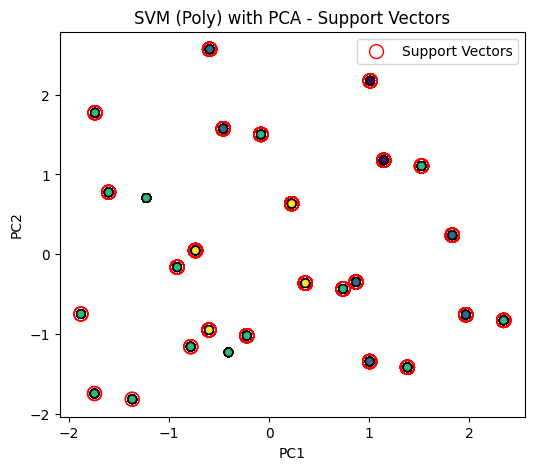

In [20]:
# 1. Encode features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = encoder.fit_transform(x)

# 2. Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# 3. PCA (reduce to 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Encode labels (for coloring)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 5. Train SVM (poly)
svm = SVC(kernel='poly')
svm.fit(X_pca, y)

# 6. Plot data
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded, cmap='viridis', edgecolors='k')

# 7. Highlight support vectors
plt.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
            facecolors='none', edgecolors='red', s=100, label='Support Vectors')

plt.title("SVM (Poly) with PCA - Support Vectors")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

## **Confusion matrix for SVM**

In [21]:

all_true = []
all_pred = []

for train_index, test_index in skf.split(x, y):

    X_train, X_test = scale(x, train_index, test_index)
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    svm = SVC(kernel='poly', random_state=0)
    svm.fit(X_train, y_train)

    y_pred = svm.predict(X_test)

    all_true.extend(y_test)
    all_pred.extend(y_pred)

cm = confusion_matrix(all_true, all_pred)

print("Confusion Matrix:")
print("Rows = Actual, Columns = Predicted")
print(cm)

Confusion Matrix:
Rows = Actual, Columns = Predicted
[[ 377    5    0    2]
 [  12   53    0    4]
 [  13    2 1195    0]
 [   4    0    0   61]]


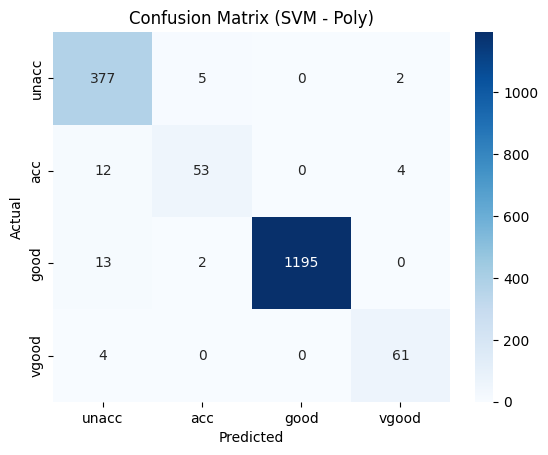

In [22]:
labels = ["unacc", "acc", "good", "vgood"]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix (SVM - Poly)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### **MLP**

In [23]:
#Importing the essential libraries required for this part.
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score,precision_score,recall_score,confusion_matrix


In [24]:

acc_list = []
f1_list = []
precision_list = []
sensitivity_list = []
specificity_list = []

for train_index, test_index in skf.split(x, y):

    X_train, X_test = scale(x, train_index, test_index)
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    mlp = MLPClassifier(hidden_layer_sizes=(30,),
                        activation='relu',
                        solver='adam',
                        batch_size=200,
                        max_iter=500,
                        learning_rate_init=0.01,
                        random_state=0)

    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)

    # metrics
    acc_list.append(accuracy_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred, average='weighted'))
    precision_list.append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
    sensitivity_list.append(recall_score(y_test, y_pred, average='macro'))

    # specificity
    cm = confusion_matrix(y_test, y_pred)

    spec = []
    for i in range(len(cm)):
        FP = cm[:, i].sum() - cm[i, i]
        TN = cm.sum() - (cm[i, :].sum() + FP)
        spec.append(TN / (TN + FP))

    specificity_list.append(np.mean(spec))

print("MLP Results")
print("Accuracy =", np.mean(acc_list), "±", np.std(acc_list))
print("F1 Score =", np.mean(f1_list), "±", np.std(f1_list))
print("Precision Score =", np.mean(precision_list), "±", np.std(precision_list))
print("Sensitivity =", np.mean(sensitivity_list), "±", np.std(sensitivity_list))
print("Specificity =", np.mean(specificity_list), "±", np.std(specificity_list))

MLP Results
Accuracy = 0.9936332411828769 ± 0.003373381239218735
F1 Score = 0.9935722481073983 ± 0.0034249617665595257
Precision Score = 0.9938921999964837 ± 0.003201980326223044
Sensitivity = 0.9854718845747554 ± 0.02158663524668654
Specificity = 0.9977285014355026 ± 0.001003621483152669


## Confusion matrix for MLP

In [25]:
all_true = []
all_pred = []

for train_index, test_index in skf.split(x, y):

    X_train, X_test = scale(x, train_index, test_index)
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    mlp = MLPClassifier(hidden_layer_sizes=(30,), max_iter=500,
                        learning_rate_init=0.01, random_state=0)

    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)

    all_true.extend(y_test)
    all_pred.extend(y_pred)

cm = confusion_matrix(all_true, all_pred)
print("Confusion Matrix:")
print("Rows = Actual, Columns = Predicted")
print(cm)

Confusion Matrix:
Rows = Actual, Columns = Predicted
[[ 381    2    1    0]
 [   3   66    0    0]
 [   5    0 1205    0]
 [   0    0    0   65]]


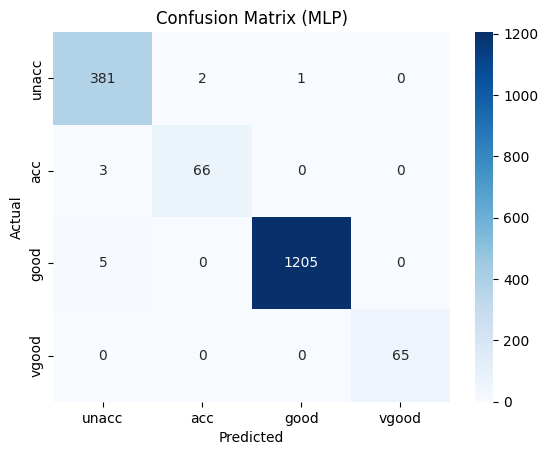

In [26]:
labels = ["unacc", "acc", "good", "vgood"]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.title("Confusion Matrix (MLP)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Accuracy Comparison:**

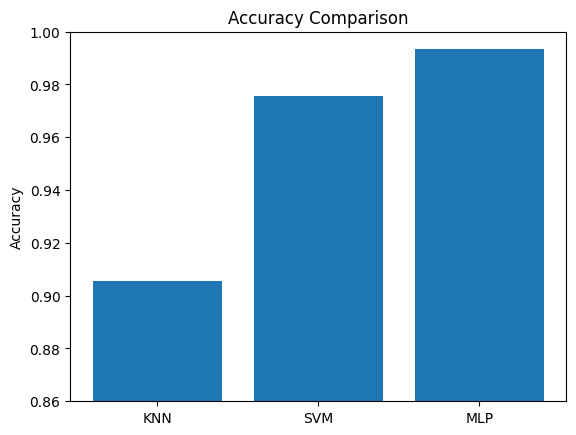

In [27]:


models = ['KNN', 'SVM', 'MLP']
accuracy = [0.9057, 0.9757, 0.9936]

plt.figure()
plt.bar(models, accuracy)

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.86, 1.0)

plt.show()